In [3]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
# ==========================================
# Dataset Information
# ==========================================

print(df.head())
print(df.info())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [6]:
# ==========================================
# Data Preprocessing
# ==========================================

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


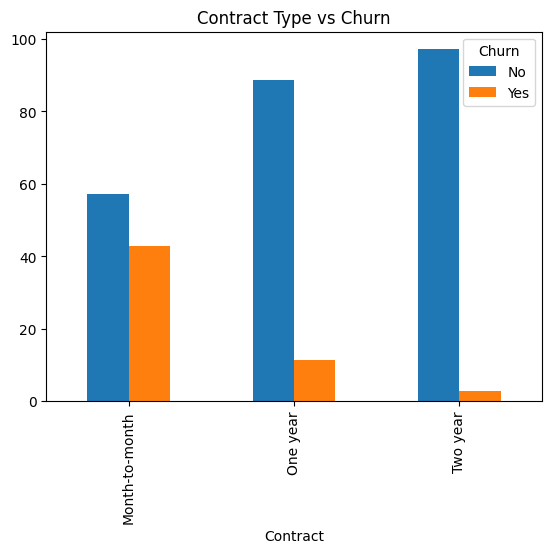

In [7]:
# ==========================================
# Contract Type Analysis
# ==========================================

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

contract_churn.plot(kind='bar')
plt.title("Contract Type vs Churn")
plt.show()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


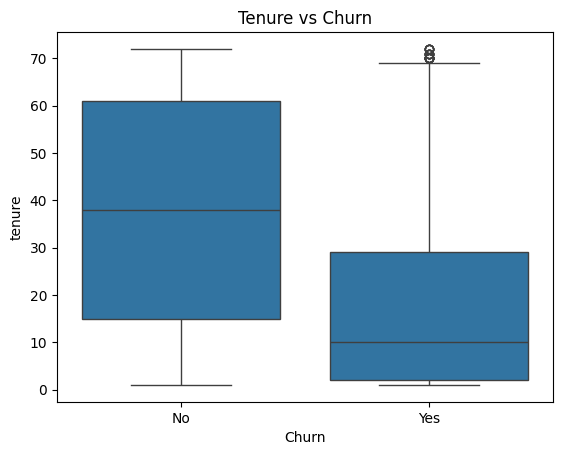

In [8]:
# ==========================================
# Tenure Analysis
# ==========================================

print(df.groupby('Churn')['tenure'].mean())

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


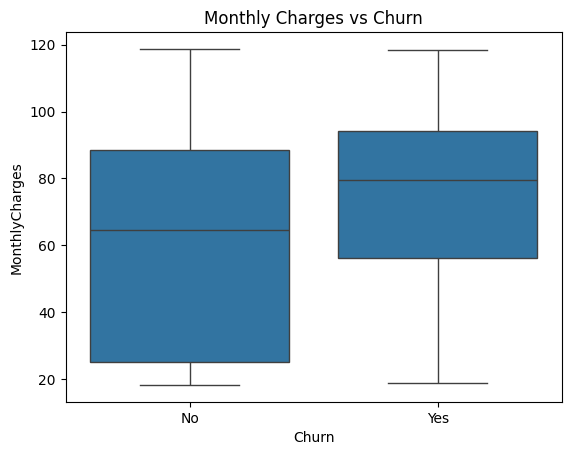

In [9]:
# ==========================================
# Monthly Charges Analysis
# ==========================================

print(df.groupby('Churn')['MonthlyCharges'].mean())

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


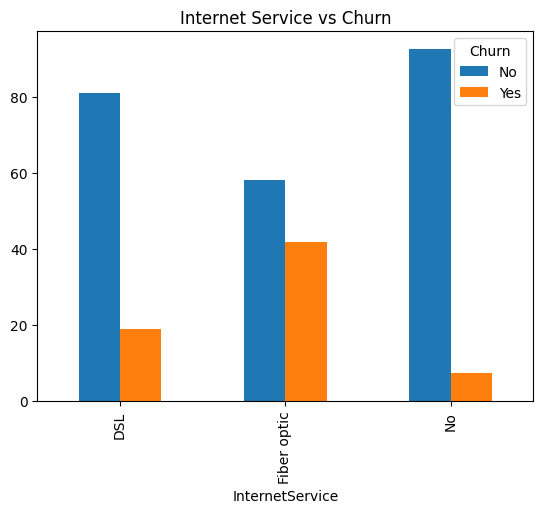

In [10]:
# ==========================================
# Internet Service Analysis
# ==========================================

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn)

internet_churn.plot(kind='bar')
plt.title("Internet Service vs Churn")
plt.show()

In [12]:
# ==========================================
# Feature Encoding
# ==========================================

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])


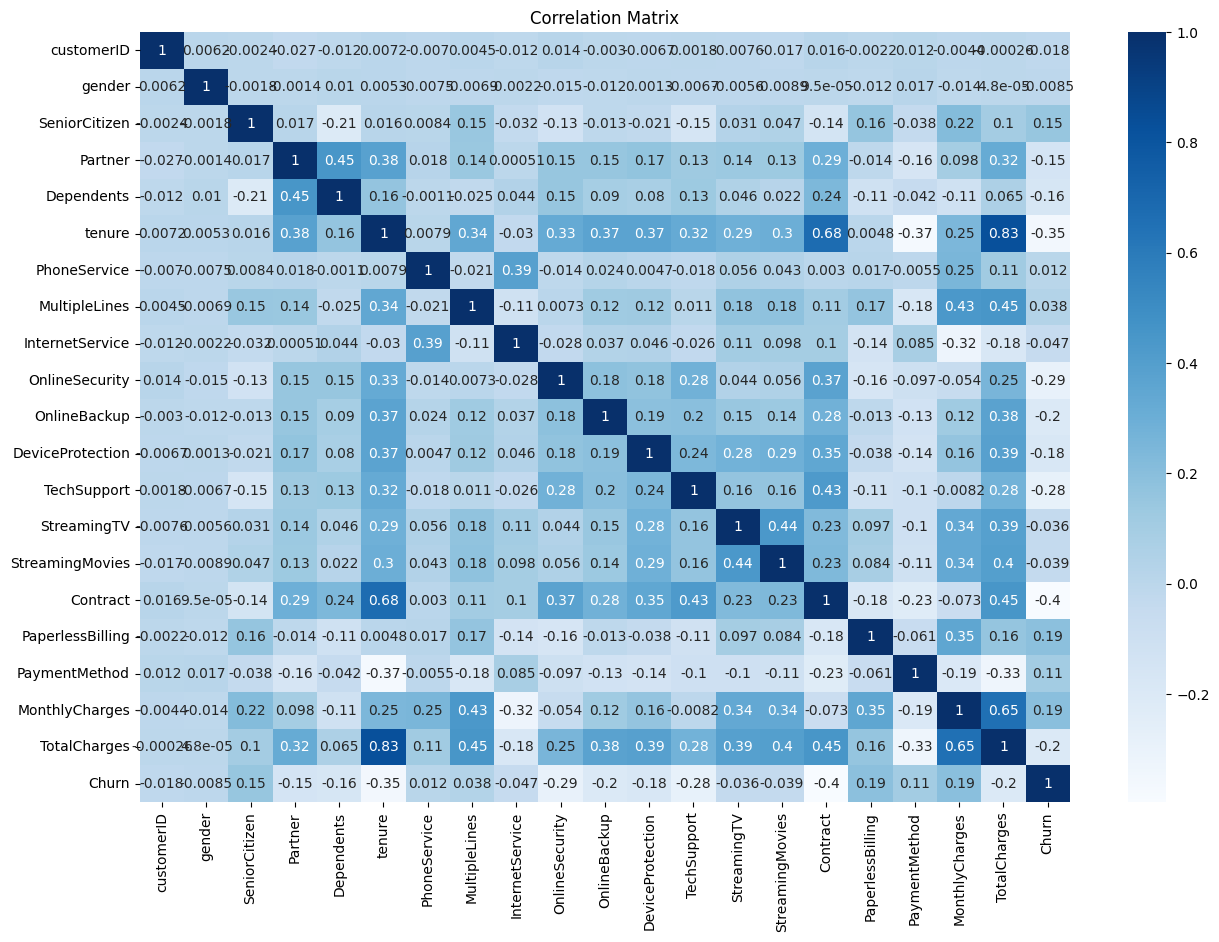

In [13]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='Blues',
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
# ==========================================
# Feature Selection
# ==========================================

X = df.drop(
    ['customerID','Churn'],
    axis=1
)

y = df['Churn']

In [15]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# ==========================================
# Logistic Regression Model
# ==========================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# ==========================================
# Decision Tree Model
# ==========================================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


In [18]:
# ==========================================
# Random Forest Model
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [19]:
# ==========================================
# Model Evaluation
# ==========================================

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nRandom Forest Report")
print(classification_report(y_test,rf_pred))

Logistic Regression Accuracy:
0.7853589196872779

Decision Tree Accuracy:
0.7249466950959488

Random Forest Accuracy:
0.7924662402274343

Random Forest Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



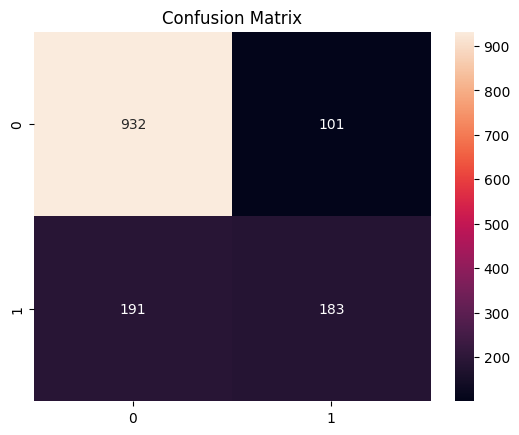

In [20]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()


Top 10 Important Features
            Feature  Importance
18     TotalCharges    0.184953
17   MonthlyCharges    0.178014
4            tenure    0.154510
14         Contract    0.080585
16    PaymentMethod    0.052031
8    OnlineSecurity    0.048509
11      TechSupport    0.047581
7   InternetService    0.026813
0            gender    0.026715
9      OnlineBackup    0.025883


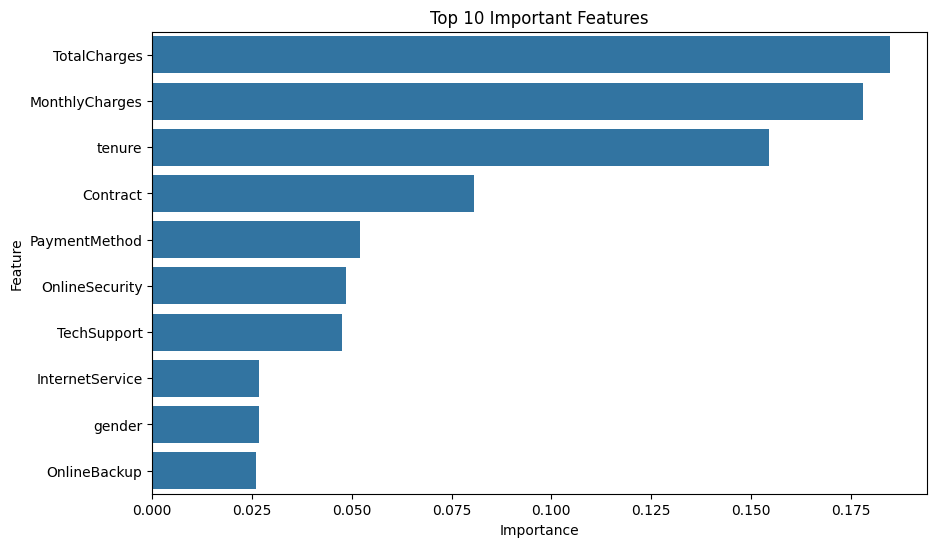

In [21]:
# ==========================================
# Feature Importance Analysis
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [22]:
# ==========================================
# Churn Risk Prediction
# ==========================================

risk_probability = rf.predict_proba(X_test)

risk_score = risk_probability[:,1] * 100

risk_df = pd.DataFrame({
    'Risk Score (%)': risk_score
})

print(risk_df.head())

   Risk Score (%)
0             0.0
1            10.0
2            75.0
3            21.0
4            24.0


In [23]:
# ==========================================
# Retention Recommendation Engine
# ==========================================

def recommendation(score):

    if score >= 70:
        return "Offer Discount"

    elif score >= 40:
        return "Offer Loyalty Benefits"

    else:
        return "No Action Required"

risk_df['Recommendation'] = risk_df[
    'Risk Score (%)'
].apply(recommendation)

print(risk_df.head(20))

    Risk Score (%)          Recommendation
0              0.0      No Action Required
1             10.0      No Action Required
2             75.0          Offer Discount
3             21.0      No Action Required
4             24.0      No Action Required
5             55.0  Offer Loyalty Benefits
6             13.0      No Action Required
7             67.0  Offer Loyalty Benefits
8             22.0      No Action Required
9              2.0      No Action Required
10            50.0  Offer Loyalty Benefits
11            27.0      No Action Required
12             0.0      No Action Required
13            20.0      No Action Required
14             7.0      No Action Required
15            31.0      No Action Required
16           100.0          Offer Discount
17             9.0      No Action Required
18            33.0      No Action Required
19            25.0      No Action Required


In [26]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.785359
1        Decision Tree  0.724947
2        Random Forest  0.792466
